# Heston Vol Surface Training Data — Fully Stochastic Parameters

Generates implied vol surface data for **N_ASSETS = 5** correlated assets over **N_DAYS = 1000** synthetic trading days.

### Key idea: ALL four Heston parameters are stochastic

Every Heston parameter evolves across days as a correlated Ornstein–Uhlenbeck process. Cross-asset shocks share the **same** correlation matrix $C_\theta$ so a market-wide stress event hits all parameters simultaneously.

| Parameter | OU type | Range | Role |
|-----------|---------|-------|------|
| θ (theta) | Standard OU in natural space | [0.005, 0.500] | Long-run variance |
| κ (kappa) | Log-OU (OU on log κ) | [0.3, 10.0] | Variance mean-reversion speed |
| ξ (xi)    | Log-OU (OU on log ξ) | [0.05, 1.50] | Vol-of-vol |
| ρ (rho)   | Standard OU in natural space | [−0.95, −0.05] | Spot-variance correlation |
| v₀        | = θ(d) each day | — | Initial variance |

Within each day the Heston model is used with **fixed** parameters; variation is only across days.

### Output files
- `../Data/heston_multiasset_training.npz` — 2000 days, train/val split
- `../Data/heston_multiasset_ood_test.npz` — 200 days, completely independent seed

In [15]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from numpy.polynomial.legendre import leggauss
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('Imports OK')

Imports OK


## Configuration

All constants in one place: OU parameters for each of the four stochastic Heston processes, grid parameters, and data layout.

In [55]:
# ── Simulation scale ──────────────────────────────────────────────────────────
N_ASSETS = 5
N_DAYS   = 5000
SEED     = 42

# ── Market conventions ────────────────────────────────────────────────────────
S0 = 100.0
R  = 0.05     # risk-free rate

# ── Observation grid ──────────────────────────────────────────────────────────
MATURITY_BINS = np.array([0.25, 0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 2.00])
N_MAT_BINS    = len(MATURITY_BINS)

# Log-moneyness sampling: N(0, LM_STD) clipped to ±LM_CLIP  (ATM-centred)
LM_STD  = 0.25
LM_CLIP = 0.50

# Maturity sampling weights: normal centred at T_MEAN with std T_STD
_T_MEAN, _T_STD = 0.50, 0.80
_raw_w          = np.exp(-0.5 * ((MATURITY_BINS - _T_MEAN) / _T_STD) ** 2)
T_SAMPLE_WEIGHTS = (_raw_w / _raw_w.sum()).astype(np.float64)

# ── Training data layout (must match notebook 02) ─────────────────────────────
N_CTX_POOL = 400   # first N_CTX_POOL points per day = context pool
N_TGT_POOL = 400   # next  N_TGT_POOL points per day = target pool
N_TOTAL    = N_CTX_POOL + N_TGT_POOL   # points per day

# ── OU parameters for theta (long-run variance) ───────────────────────────────
# Standard OU in natural space: θ(d+1) = θ(d) + κ(θ̄ - θ(d)) + σ·ε
THETA_BAR = np.array([0.040, 0.060, 0.030, 0.080, 0.050])  # long-run means
KAPPA_TH  = np.array([0.050, 0.040, 0.060, 0.030, 0.050])  # mean-reversion speeds
SIGMA_TH  = np.array([0.006, 0.008, 0.005, 0.010, 0.007])  # noise amplitudes
THETA_MIN, THETA_MAX = 0.005, 0.500

# ── OU parameters for kappa (variance mean-reversion speed) ──────────────────
# Log-OU: log(κ) follows OU so κ stays positive
KAPPA_BAR = np.array([2.0, 1.5, 3.0, 1.0, 4.0])    # long-run means for κ
KAPPA_K   = np.array([0.04] * N_ASSETS)              # OU speed for κ
SIGMA_K   = np.array([0.08] * N_ASSETS)              # noise in log(κ) space
KAPPA_MIN, KAPPA_MAX = 0.3, 10.0

# ── OU parameters for xi (vol-of-vol) ─────────────────────────────────────────
# Log-OU: log(ξ) follows OU
XI_BAR   = np.array([0.30, 0.50, 0.20, 0.55, 0.40])  # long-run means for ξ
KAPPA_XI = np.array([0.04] * N_ASSETS)                 # OU speed for ξ
SIGMA_XI = np.array([0.10] * N_ASSETS)                 # noise in log(ξ) space
XI_MIN, XI_MAX = 0.05, 1.50

# ── OU parameters for rho (spot-variance correlation) ─────────────────────────
# Standard OU in natural space (negative values natural for equity)
RHO_BAR   = np.array([-0.70, -0.50, -0.80, -0.35, -0.60])  # long-run means
KAPPA_RHO = np.array([0.04] * N_ASSETS)                      # OU speed
SIGMA_RHO = np.array([0.025] * N_ASSETS)                     # noise amplitude
RHO_MIN, RHO_MAX = -0.95, -0.05

# ── Print summary ─────────────────────────────────────────────────────────────
print('=' * 65)
print(f'  Assets : {N_ASSETS}    Days : {N_DAYS}    Points/day : {N_TOTAL}')
print(f'  Context pool : [0, {N_CTX_POOL})   Target pool : [{N_CTX_POOL}, {N_TOTAL})')
print('=' * 65)
print()
print('OU long-run means per parameter:')
print(f'  {"asset":<10} {"theta_bar":>10} {"kappa_bar":>10} {"xi_bar":>8} {"rho_bar":>8}')
for i in range(N_ASSETS):
    print(f'  asset_{i:<5} {THETA_BAR[i]:>10.3f} {KAPPA_BAR[i]:>10.2f}'
          f' {XI_BAR[i]:>8.2f} {RHO_BAR[i]:>8.2f}')
print()
print('Maturity bins :', MATURITY_BINS)
print('T weights     :', np.round(T_SAMPLE_WEIGHTS, 3))

  Assets : 5    Days : 5000    Points/day : 800
  Context pool : [0, 400)   Target pool : [400, 800)

OU long-run means per parameter:
  asset       theta_bar  kappa_bar   xi_bar  rho_bar
  asset_0          0.040       2.00     0.30    -0.70
  asset_1          0.060       1.50     0.50    -0.50
  asset_2          0.030       3.00     0.20    -0.80
  asset_3          0.080       1.00     0.55    -0.35
  asset_4          0.050       4.00     0.40    -0.60

Maturity bins : [0.25 0.5  0.75 1.   1.25 1.5  1.75 2.  ]
T weights     : [0.18  0.189 0.18  0.155 0.122 0.086 0.056 0.033]


## Cross-Asset Correlation Matrix

All four parameter processes share the **same** correlation matrix $C_\theta$. This means a vol regime shift (e.g., a VIX spike) simultaneously affects θ, κ, ξ, and ρ across all assets.

High positive correlations (0.55–0.76) model equity-like co-movement.

In [56]:
THETA_CORR = np.array([
    [1.00, 0.72, 0.63, 0.67, 0.76],
    [0.72, 1.00, 0.58, 0.62, 0.70],
    [0.63, 0.58, 1.00, 0.55, 0.62],
    [0.67, 0.62, 0.55, 1.00, 0.65],
    [0.76, 0.70, 0.62, 0.65, 1.00],
])

# Verify positive-definiteness
eigvals = np.linalg.eigvalsh(THETA_CORR)
print('Theta correlation matrix:')
for i in range(N_ASSETS):
    row = '  '.join(f'{THETA_CORR[i,j]:.2f}' for j in range(N_ASSETS))
    print(f'  [{row}]')
print()
print(f'Eigenvalues : {np.round(eigvals, 4)}')
print(f'Min eigenvalue : {eigvals.min():.4f}  ->  {"PD OK" if eigvals.min() > 0 else "NOT PD — fix matrix"}')
assert eigvals.min() > 0, 'Correlation matrix is not positive definite!'

CHOL_TH = np.linalg.cholesky(THETA_CORR)
print(f'Cholesky factor computed: {CHOL_TH.shape}')
print()
print('Off-diagonal range:', f'[{THETA_CORR[THETA_CORR < 1].min():.2f},',
      f'{THETA_CORR[THETA_CORR < 1].max():.2f}]')
print()
print('Note: all four parameter processes (θ, κ, ξ, ρ) use this same Cholesky factor.')

Theta correlation matrix:
  [1.00  0.72  0.63  0.67  0.76]
  [0.72  1.00  0.58  0.62  0.70]
  [0.63  0.58  1.00  0.55  0.62]
  [0.67  0.62  0.55  1.00  0.65]
  [0.76  0.70  0.62  0.65  1.00]

Eigenvalues : [0.2369 0.3023 0.3918 0.4622 3.6069]
Min eigenvalue : 0.2369  ->  PD OK
Cholesky factor computed: (5, 5)

Off-diagonal range: [0.55, 0.76]

Note: all four parameter processes (θ, κ, ξ, ρ) use this same Cholesky factor.


## OU Simulation Helpers

Two helper functions:

- **`simulate_ou_natural`** — standard linear OU with additive noise and hard clip (used for θ and ρ)
- **`simulate_ou_logspace`** — OU on log(x), then exponentiate and clip (used for κ and ξ, guarantees positivity)

Both use the shared Cholesky factor for cross-asset correlation. Parameters are independent **within** each asset (innovations across κ, ξ, ρ, θ are independent — only cross-asset correlation is modelled).

In [57]:
def simulate_ou_natural(n_days, x_bar, kappa, sigma, chol, x_min, x_max, seed):
    """
    Standard OU in natural space — linear drift, additive noise, hard clip.

    x(d+1) = x(d) + kappa * (x_bar - x(d)) + sigma * chol @ z(d),  z ~ N(0,I)
    Returns (n_days, N) array, initialised at x_bar.
    """
    N   = len(x_bar)
    rng = np.random.default_rng(seed)
    X   = np.zeros((n_days, N))
    X[0] = x_bar.copy()
    for d in range(1, n_days):
        z     = rng.standard_normal(N)
        eps   = chol @ z
        drift = kappa * (x_bar - X[d - 1])
        X[d]  = np.clip(X[d-1] + drift + sigma * eps, x_min, x_max)
    return X


def simulate_ou_logspace(n_days, x_bar, kappa, sigma, chol, x_min, x_max, seed):
    """
    Log-OU: OU on log(x), exponentiate, clip.

    log_x(d+1) = log_x(d) + kappa * (log(x_bar) - log_x(d)) + sigma * chol @ z(d)
    Returns (n_days, N) array in original (not log) space, initialised at x_bar.
    """
    N       = len(x_bar)
    rng     = np.random.default_rng(seed)
    log_bar = np.log(x_bar)
    logX    = np.zeros((n_days, N))
    logX[0] = log_bar.copy()
    for d in range(1, n_days):
        z      = rng.standard_normal(N)
        eps    = chol @ z
        drift  = kappa * (log_bar - logX[d - 1])
        logX[d] = logX[d-1] + drift + sigma * eps
    X = np.exp(logX)
    return np.clip(X, x_min, x_max)


print('OU simulation helpers defined.')

OU simulation helpers defined.


## Simulate All 4 OU Paths

Each parameter uses a different seed (SEED, SEED+1, SEED+2, SEED+3) so the four processes are independent within each asset.

In [58]:
# θ — standard OU, seed = SEED
theta_path = simulate_ou_natural(
    N_DAYS, THETA_BAR, KAPPA_TH, SIGMA_TH, CHOL_TH, THETA_MIN, THETA_MAX, seed=SEED
)

# κ — log-OU, seed = SEED+1
kappa_path = simulate_ou_logspace(
    N_DAYS, KAPPA_BAR, KAPPA_K, SIGMA_K, CHOL_TH, KAPPA_MIN, KAPPA_MAX, seed=SEED+1
)

# ξ — log-OU, seed = SEED+2
xi_path = simulate_ou_logspace(
    N_DAYS, XI_BAR, KAPPA_XI, SIGMA_XI, CHOL_TH, XI_MIN, XI_MAX, seed=SEED+2
)

# ρ — standard OU, seed = SEED+3
rho_path = simulate_ou_natural(
    N_DAYS, RHO_BAR, KAPPA_RHO, SIGMA_RHO, CHOL_TH, RHO_MIN, RHO_MAX, seed=SEED+3
)

# v0 = theta each day
v0_path = theta_path.copy()

print(f'theta_path  shape: {theta_path.shape}  (days x assets)')
print(f'kappa_path  shape: {kappa_path.shape}')
print(f'xi_path     shape: {xi_path.shape}')
print(f'rho_path    shape: {rho_path.shape}')
print()

# Per-parameter summary statistics
for name, path, bar in [
    ('theta', theta_path, THETA_BAR),
    ('kappa', kappa_path, KAPPA_BAR),
    ('xi',    xi_path,    XI_BAR),
    ('rho',   rho_path,   RHO_BAR),
]:
    print(f'  {name} statistics:')
    print(f'    {"asset":<10} {"bar":>8} {"mean":>8} {"std":>8} {"min":>8} {"max":>8}')
    for i in range(N_ASSETS):
        p = path[:, i]
        print(f'    asset_{i:<5} {bar[i]:>8.4f} {p.mean():>8.4f} {p.std():>8.4f}'
              f' {p.min():>8.4f} {p.max():>8.4f}')
    print()

theta_path  shape: (5000, 5)  (days x assets)
kappa_path  shape: (5000, 5)
xi_path     shape: (5000, 5)
rho_path    shape: (5000, 5)

  theta statistics:
    asset           bar     mean      std      min      max
    asset_0       0.0400   0.0408   0.0179   0.0050   0.1050
    asset_1       0.0600   0.0625   0.0290   0.0050   0.1608
    asset_2       0.0300   0.0304   0.0136   0.0050   0.0793
    asset_3       0.0800   0.0866   0.0404   0.0050   0.2170
    asset_4       0.0500   0.0529   0.0233   0.0050   0.1301

  kappa statistics:
    asset           bar     mean      std      min      max
    asset_0       2.0000   1.9871   0.5489   0.6261   5.9638
    asset_1       1.5000   1.5191   0.4113   0.4816   3.5163
    asset_2       3.0000   2.9755   0.7984   1.0850   6.0576
    asset_3       1.0000   0.9945   0.2772   0.3414   2.3515
    asset_4       4.0000   4.0405   1.0694   1.2406   9.5589

  xi statistics:
    asset           bar     mean      std      min      max
    asset_0      

## Plot All 4 Parameter Paths

2×2 grid of figures, each showing the 5-asset time series for one parameter.

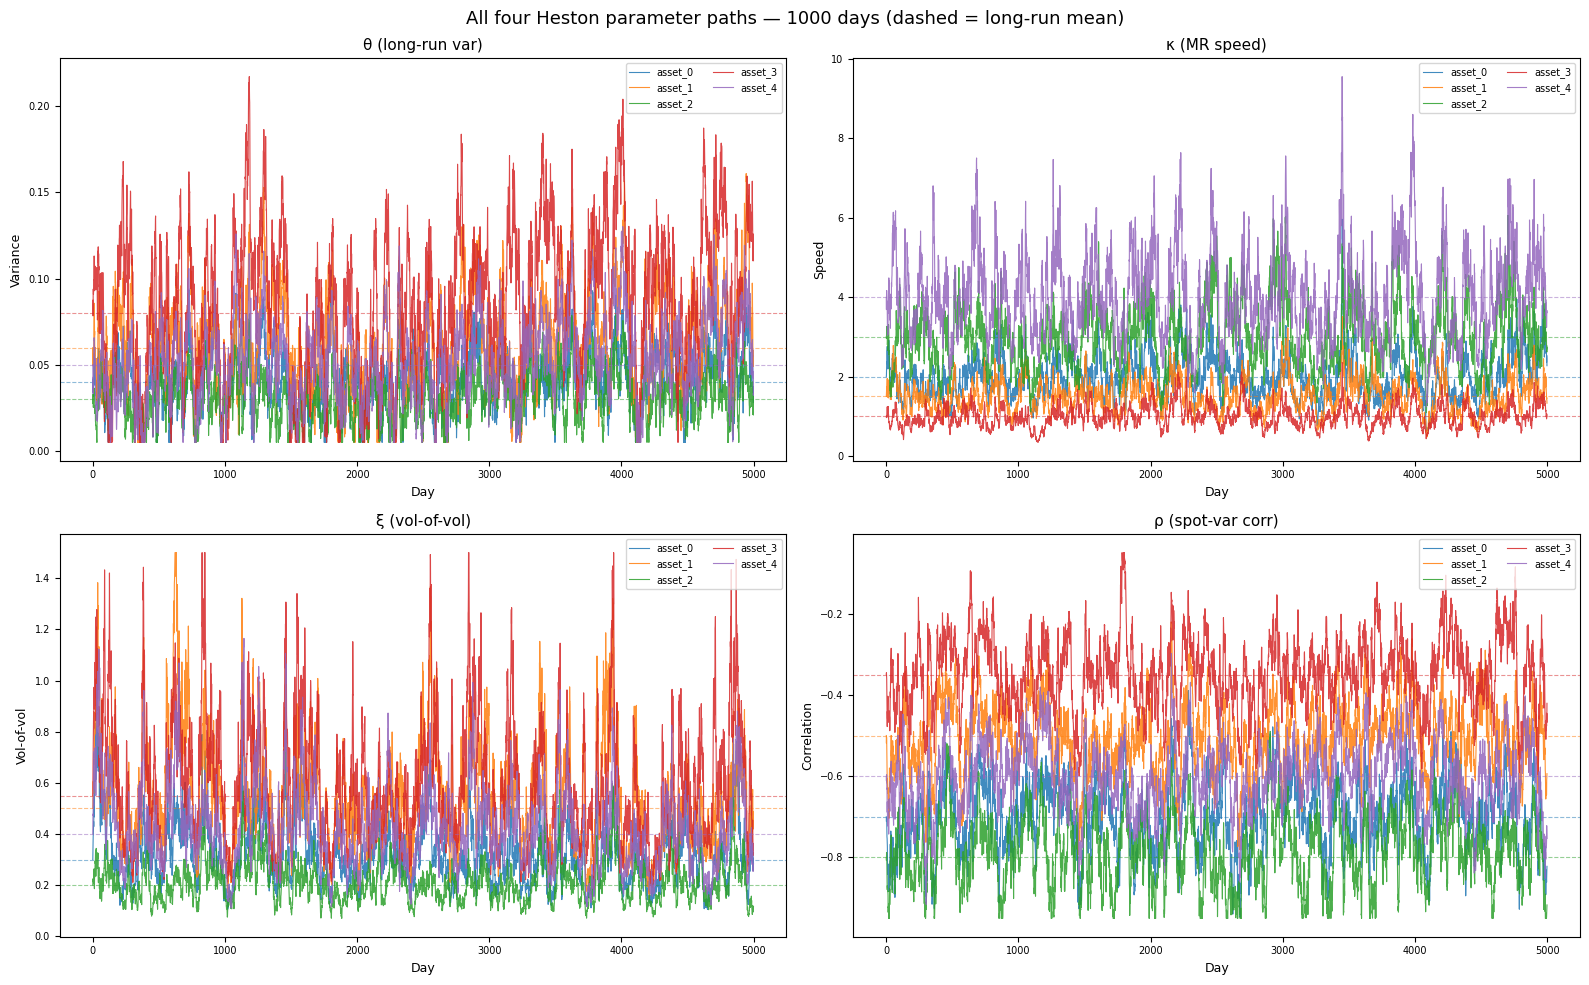

In [59]:
cmap   = plt.cm.tab10
days_x = np.arange(N_DAYS)

param_info = [
    ('θ (long-run var)',  theta_path, THETA_BAR, None,     'Variance'),
    ('κ (MR speed)',      kappa_path, KAPPA_BAR, None,     'Speed'),
    ('ξ (vol-of-vol)',    xi_path,    XI_BAR,    None,     'Vol-of-vol'),
    ('ρ (spot-var corr)', rho_path,   RHO_BAR,   None,     'Correlation'),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes_flat = axes.flatten()

for ax, (title, path, bar, _, ylabel) in zip(axes_flat, param_info):
    for i in range(N_ASSETS):
        ax.plot(days_x, path[:, i], color=cmap(i), lw=0.8, alpha=0.85, label=f'asset_{i}')
        ax.axhline(bar[i], color=cmap(i), lw=0.8, ls='--', alpha=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Day', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.legend(fontsize=7, loc='upper right', ncol=2)
    ax.tick_params(labelsize=7)

fig.suptitle('All four Heston parameter paths — 1000 days (dashed = long-run mean)', fontsize=13)
plt.tight_layout()
plt.show()

## Parameter Statistics and Feller Condition

The Feller condition $2\kappa\theta \geq \xi^2$ ensures strict positivity of the variance process. Because all three parameters are now stochastic, we compute the fraction of days where the condition is violated per asset.

In [62]:
print('Feller condition check: 2κθ >= ξ²')
print(f'  {"asset":<10} {"mean(2κθ)":>12} {"mean(ξ²)":>10} {"viol_frac":>12} {"mean_lhs-rhs":>14}')
for i in range(N_ASSETS):
    lhs = 2 * kappa_path[:, i] * theta_path[:, i]
    rhs = xi_path[:, i] ** 2
    viol_frac = (lhs < rhs).mean()
    margin    = (lhs - rhs).mean()
    print(f'  asset_{i:<5} {lhs.mean():>12.4f} {rhs.mean():>10.4f}'
          f' {viol_frac:>12.3f} {margin:>14.4f}')
print()
print('  (Fourier pricer handles Feller violations correctly.)')
print()

# Empirical cross-asset correlation of theta paths
print('Empirical theta correlation matrix (vs target):')
emp_corr = np.corrcoef(theta_path.T)
for i in range(N_ASSETS):
    row_emp = '  '.join(f'{emp_corr[i,j]:>6.3f}' for j in range(N_ASSETS))
    row_tgt = '  '.join(f'{THETA_CORR[i,j]:>6.3f}' for j in range(N_ASSETS))
    print(f'  asset_{i}  emp: [{row_emp}]')
    print(f'           tgt: [{row_tgt}]')

Feller condition check: 2κθ >= ξ²
  asset         mean(2κθ)   mean(ξ²)    viol_frac   mean_lhs-rhs
  asset_0           0.1633     0.1169        0.313         0.0464
  asset_1           0.1908     0.3369        0.665        -0.1461
  asset_2           0.1806     0.0505        0.080         0.1300
  asset_3           0.1741     0.4148        0.758        -0.2406
  asset_4           0.4317     0.2051        0.189         0.2266

  (Fourier pricer handles Feller violations correctly.)

Empirical theta correlation matrix (vs target):
  asset_0  emp: [ 1.000   0.735   0.648   0.642   0.751]
           tgt: [ 1.000   0.720   0.630   0.670   0.760]
  asset_1  emp: [ 0.735   1.000   0.631   0.610   0.740]
           tgt: [ 0.720   1.000   0.580   0.620   0.700]
  asset_2  emp: [ 0.648   0.631   1.000   0.570   0.667]
           tgt: [ 0.630   0.580   1.000   0.550   0.620]
  asset_3  emp: [ 0.642   0.610   0.570   1.000   0.674]
           tgt: [ 0.670   0.620   0.550   1.000   0.650]
  asset_4

## Heston Fourier Pricer — Lewis Formula

Exact European call prices via Gauss–Legendre quadrature on the Lewis (2001) formula.
No Monte Carlo noise. Groups points by (asset, T) so GL nodes are reused across strikes.

In [63]:
# ── Gauss-Legendre nodes mapped to [0, U_MAX] ─────────────────────────────────
_U_MAX        = 200.0
_N_GL         = 96
_xi_gl, _w_gl = leggauss(_N_GL)
_U_NODES      = (_xi_gl + 1.0) / 2.0 * _U_MAX
_W_NODES      = _w_gl  / 2.0 * _U_MAX

print(f'GL quadrature: {_N_GL} nodes on [0, {_U_MAX}]')


def _heston_cf_lewis(u_real, T, v0, kappa, theta, xi, rho):
    """Characteristic function of log(S_T / F_T) evaluated at u = u_real - i/2."""
    u = u_real - 0.5j
    a = kappa - rho * xi * 1j * u
    d = np.sqrt(a**2 + xi**2 * (u**2 + 1j * u))
    g = (a - d) / (a + d)
    h = np.exp(-d * T)
    C = (kappa * theta / xi**2
         * ((a - d) * T - 2.0 * np.log((1.0 - g * h) / (1.0 - g))))
    D = (a - d) / xi**2 * (1.0 - h) / (1.0 - g * h)
    return np.exp(C + D * v0)


def heston_call_lewis(S0, r, K_arr, T, v0, kappa, theta, xi, rho):
    """Lewis formula via GL quadrature. K_arr may be a vector."""
    F    = S0 * np.exp(r * T)
    k    = np.log(K_arr / F)          # forward log-moneyness
    disc = np.exp(-r * T)
    cf   = _heston_cf_lewis(_U_NODES, T, v0, kappa, theta, xi, rho)
    base = cf / (_U_NODES**2 + 0.25)
    M    = np.real(np.exp(-1j * np.outer(k, _U_NODES)) * base[None, :])
    I    = M @ _W_NODES
    calls = S0 - np.sqrt(K_arr * F) * disc / np.pi * I
    return np.clip(calls, np.maximum(S0 - K_arr * disc, 0.0), S0)


# ── Vectorised Black-Scholes IV solver ────────────────────────────────────────
def _bs_call_vec(K, T, iv):
    sqT = np.sqrt(np.where(T > 0, T, 1e-10))
    iv  = np.where(iv > 0, iv, 1e-8)
    d1  = (np.log(S0 / K) + (R + 0.5 * iv**2) * T) / (iv * sqT)
    return S0 * norm.cdf(d1) - K * np.exp(-R * T) * norm.cdf(d1 - iv * sqT)

def _bs_vega_vec(K, T, iv):
    sqT = np.sqrt(np.where(T > 0, T, 1e-10))
    iv  = np.where(iv > 0, iv, 1e-8)
    d1  = (np.log(S0 / K) + (R + 0.5 * iv**2) * T) / (iv * sqT)
    return S0 * norm.pdf(d1) * sqT

def _implied_vol_vec(prices, K, T, n_iter=80):
    intrinsic = np.maximum(S0 - K * np.exp(-R * T), 0.0)
    valid = prices > intrinsic + 1e-10
    iv = np.full_like(prices, 0.30)
    for _ in range(n_iter):
        p    = _bs_call_vec(K, T, iv)
        vega = _bs_vega_vec(K, T, iv)
        mask = valid & (vega > 1e-14)
        iv   = np.where(mask, iv - (p - prices) / vega, iv)
        iv   = np.where(valid, iv.clip(1e-8, 10.0), iv)
    p_final = _bs_call_vec(K, T, iv)
    bad = ~valid | (np.abs(p_final - prices) > 1e-5)
    return np.where(bad, np.nan, iv).astype(np.float32)


# Quick sanity check on asset_0 at long-run means, T=1
_test_K = np.array([90., 100., 110.])
_test_c = heston_call_lewis(S0, R, _test_K, 1.0,
                             v0=THETA_BAR[0], kappa=KAPPA_BAR[0],
                             theta=THETA_BAR[0], xi=XI_BAR[0], rho=RHO_BAR[0])
_test_iv = _implied_vol_vec(_test_c, _test_K, np.ones(3))
print(f'Sanity check (asset_0, T=1, params at long-run means):')
print(f'  K={_test_K}  IV={np.round(_test_iv*100,2)}%')

GL quadrature: 96 nodes on [0, 200.0]
Sanity check (asset_0, T=1, params at long-run means):
  K=[ 90. 100. 110.]  IV=[21.36 19.85 18.46]%


## Helper Functions: Sampling and Pricing

`compute_ivs_fourier` now accepts day-specific arrays for all four Heston parameters.

In [64]:
def sample_surface_points(rng, n_points):
    """
    Sample n_points random (lm, T, asset_id) tuples.
      lm  ~ N(0, LM_STD) clipped to +/-LM_CLIP
      T   ~ discrete over MATURITY_BINS with normal weights
      aid ~ Uniform[0, N_ASSETS)
    """
    lm  = rng.normal(0.0, LM_STD, n_points).clip(-LM_CLIP, LM_CLIP)
    t_i = rng.choice(N_MAT_BINS, size=n_points, p=T_SAMPLE_WEIGHTS)
    T   = MATURITY_BINS[t_i]
    aid = rng.integers(0, N_ASSETS, n_points)
    return lm.astype(np.float32), T.astype(np.float32), aid.astype(np.int8)


def compute_ivs_fourier(lm_arr, T_arr, aid_arr, v0_d, kappa_d, theta_d, xi_d, rho_d):
    """
    Compute IVs for all sampled points on a single day.

    All parameter arrays (v0_d, kappa_d, theta_d, xi_d, rho_d) are shape (N_ASSETS,)
    and contain day-specific values from the OU paths.
    """
    n      = len(lm_arr)
    K_arr  = (S0 * np.exp(lm_arr.astype(np.float64)))
    prices = np.zeros(n, dtype=np.float64)

    for a in range(N_ASSETS):
        mask_a = (aid_arr == a)
        if not mask_a.any():
            continue
        for T in np.unique(T_arr[mask_a]):
            mask = mask_a & (T_arr == T)
            prices[mask] = heston_call_lewis(
                S0=S0, r=R, K_arr=K_arr[mask], T=float(T),
                v0=float(v0_d[a]),    kappa=float(kappa_d[a]),
                theta=float(theta_d[a]), xi=float(xi_d[a]), rho=float(rho_d[a]),
            )

    return _implied_vol_vec(prices, K_arr, T_arr.astype(np.float64))


print('Helpers defined: sample_surface_points, compute_ivs_fourier')

Helpers defined: sample_surface_points, compute_ivs_fourier


## Main Generation Loop — Training Data

For each day:
1. Read θ(d), κ(d), ξ(d), ρ(d) from the pre-simulated OU paths; set v₀ = θ(d)
2. Sample **N_TOTAL = 800** random `(lm, T, asset_id)` points
3. Price all points with the Heston Fourier pricer using today's parameters
4. Solve for implied vols

In [65]:
import time

# Storage arrays
all_lm     = np.zeros((N_DAYS, N_TOTAL), dtype=np.float32)
all_T      = np.zeros((N_DAYS, N_TOTAL), dtype=np.float32)
all_aid    = np.zeros((N_DAYS, N_TOTAL), dtype=np.int8)
all_iv     = np.full( (N_DAYS, N_TOTAL), np.nan, dtype=np.float32)
all_params = np.zeros((N_DAYS, N_ASSETS, 5), dtype=np.float32)  # [v0, kappa, theta, xi, rho]

rng_pts   = np.random.default_rng(SEED + 10)  # separate seed for point sampling
n_dropped = 0
t0        = time.time()

for d in tqdm(range(N_DAYS), desc='Days (training)'):
    theta_d = theta_path[d]   # (N_ASSETS,)
    kappa_d = kappa_path[d]
    xi_d    = xi_path[d]
    rho_d   = rho_path[d]
    v0_d    = v0_path[d]      # = theta_d

    lm_d, T_d, aid_d = sample_surface_points(rng_pts, N_TOTAL)
    iv_d = compute_ivs_fourier(lm_d, T_d, aid_d, v0_d, kappa_d, theta_d, xi_d, rho_d)

    nan_frac = np.isnan(iv_d).mean()
    if nan_frac > 0.05:
        n_dropped += 1
        if d > 0:   # repeat previous day as fallback
            all_lm[d]  = all_lm[d - 1]
            all_T[d]   = all_T[d - 1]
            all_aid[d] = all_aid[d - 1]
            all_iv[d]  = all_iv[d - 1]
        continue

    # Fill isolated NaNs with day-mean IV
    bad = np.isnan(iv_d)
    if bad.any():
        iv_d[bad] = float(np.nanmean(iv_d))

    all_lm[d]     = lm_d
    all_T[d]      = T_d
    all_aid[d]    = aid_d
    all_iv[d]     = iv_d
    all_params[d] = np.column_stack([v0_d, kappa_d, theta_d, xi_d, rho_d])

elapsed = time.time() - t0
print(f'\nDone in {elapsed:.1f}s')
print(f'Dropped {n_dropped}/{N_DAYS} days ({100*n_dropped/N_DAYS:.1f}%) due to >5% NaN IVs')
print(f'Array shapes — lm: {all_lm.shape}  iv: {all_iv.shape}  params: {all_params.shape}')
print()
print('Global IV statistics (all days, all points):')
iv_flat = all_iv[~np.isnan(all_iv)]
print(f'  mean={iv_flat.mean():.4f}  std={iv_flat.std():.4f}',
      f'  min={iv_flat.min():.4f}  max={iv_flat.max():.4f}')
print()
print('Per-asset IV statistics:')
for a in range(N_ASSETS):
    vals = []
    for d in range(N_DAYS):
        mask = (all_aid[d] == a)
        vals.extend(all_iv[d][mask][~np.isnan(all_iv[d][mask])].tolist())
    vals = np.array(vals)
    print(f'  asset_{a}: mean={vals.mean():.4f}  std={vals.std():.4f}'
          f'  min={vals.min():.4f}  max={vals.max():.4f}')

Days (training):   0%|          | 0/5000 [00:00<?, ?it/s]

Days (training): 100%|██████████| 5000/5000 [03:42<00:00, 22.46it/s]



Done in 222.6s
Dropped 0/5000 days (0.0%) due to >5% NaN IVs
Array shapes — lm: (5000, 800)  iv: (5000, 800)  params: (5000, 5, 5)

Global IV statistics (all days, all points):
  mean=0.2249  std=0.0707   min=0.0212  max=0.5467

Per-asset IV statistics:
  asset_0: mean=0.2002  std=0.0549  min=0.0253  max=0.4277
  asset_1: mean=0.2424  std=0.0662  min=0.0269  max=0.5007
  asset_2: mean=0.1751  std=0.0467  min=0.0295  max=0.3779
  asset_3: mean=0.2806  std=0.0752  min=0.0212  max=0.5467
  asset_4: mean=0.2264  std=0.0571  min=0.0397  max=0.4412


## OOD Test Data Generation

Completely independent 200-day dataset generated with SEED=999 for the OU paths.

In [66]:
N_DAYS_OOD = 200
SEED_OOD   = 999

# Simulate OOD OU paths with independent seed
theta_path_ood = simulate_ou_natural(
    N_DAYS_OOD, THETA_BAR, KAPPA_TH, SIGMA_TH, CHOL_TH, THETA_MIN, THETA_MAX, seed=SEED_OOD
)
kappa_path_ood = simulate_ou_logspace(
    N_DAYS_OOD, KAPPA_BAR, KAPPA_K, SIGMA_K, CHOL_TH, KAPPA_MIN, KAPPA_MAX, seed=SEED_OOD+1
)
xi_path_ood = simulate_ou_logspace(
    N_DAYS_OOD, XI_BAR, KAPPA_XI, SIGMA_XI, CHOL_TH, XI_MIN, XI_MAX, seed=SEED_OOD+2
)
rho_path_ood = simulate_ou_natural(
    N_DAYS_OOD, RHO_BAR, KAPPA_RHO, SIGMA_RHO, CHOL_TH, RHO_MIN, RHO_MAX, seed=SEED_OOD+3
)
v0_path_ood = theta_path_ood.copy()

# Storage for OOD data
ood_lm     = np.zeros((N_DAYS_OOD, N_TOTAL), dtype=np.float32)
ood_T      = np.zeros((N_DAYS_OOD, N_TOTAL), dtype=np.float32)
ood_aid    = np.zeros((N_DAYS_OOD, N_TOTAL), dtype=np.int8)
ood_iv     = np.full( (N_DAYS_OOD, N_TOTAL), np.nan, dtype=np.float32)
ood_params = np.zeros((N_DAYS_OOD, N_ASSETS, 5), dtype=np.float32)

rng_ood   = np.random.default_rng(SEED_OOD + 10)
n_dropped_ood = 0
t0 = time.time()

for d in tqdm(range(N_DAYS_OOD), desc='Days (OOD test)'):
    theta_d = theta_path_ood[d]
    kappa_d = kappa_path_ood[d]
    xi_d    = xi_path_ood[d]
    rho_d   = rho_path_ood[d]
    v0_d    = v0_path_ood[d]

    lm_d, T_d, aid_d = sample_surface_points(rng_ood, N_TOTAL)
    iv_d = compute_ivs_fourier(lm_d, T_d, aid_d, v0_d, kappa_d, theta_d, xi_d, rho_d)

    nan_frac = np.isnan(iv_d).mean()
    if nan_frac > 0.05:
        n_dropped_ood += 1
        if d > 0:
            ood_lm[d]  = ood_lm[d - 1]
            ood_T[d]   = ood_T[d - 1]
            ood_aid[d] = ood_aid[d - 1]
            ood_iv[d]  = ood_iv[d - 1]
        continue

    bad = np.isnan(iv_d)
    if bad.any():
        iv_d[bad] = float(np.nanmean(iv_d))

    ood_lm[d]     = lm_d
    ood_T[d]      = T_d
    ood_aid[d]    = aid_d
    ood_iv[d]     = iv_d
    ood_params[d] = np.column_stack([v0_d, kappa_d, theta_d, xi_d, rho_d])

elapsed = time.time() - t0
print(f'\nOOD done in {elapsed:.1f}s')
print(f'Dropped {n_dropped_ood}/{N_DAYS_OOD} OOD days')
print(f'Array shapes — lm: {ood_lm.shape}  iv: {ood_iv.shape}')
ood_flat = ood_iv[~np.isnan(ood_iv)]
print(f'OOD IV stats: mean={ood_flat.mean():.4f}  std={ood_flat.std():.4f}'
      f'  min={ood_flat.min():.4f}  max={ood_flat.max():.4f}')

Days (OOD test):   0%|          | 0/200 [00:00<?, ?it/s]

Days (OOD test): 100%|██████████| 200/200 [00:10<00:00, 19.20it/s]


OOD done in 10.4s
Dropped 0/200 OOD days
Array shapes — lm: (200, 800)  iv: (200, 800)
OOD IV stats: mean=0.2278  std=0.0679  min=0.0341  max=0.5045


## Diagnostic Plots — IV Smile Examples

Sample IV smiles from 3 random days (training data). Colour encodes maturity.

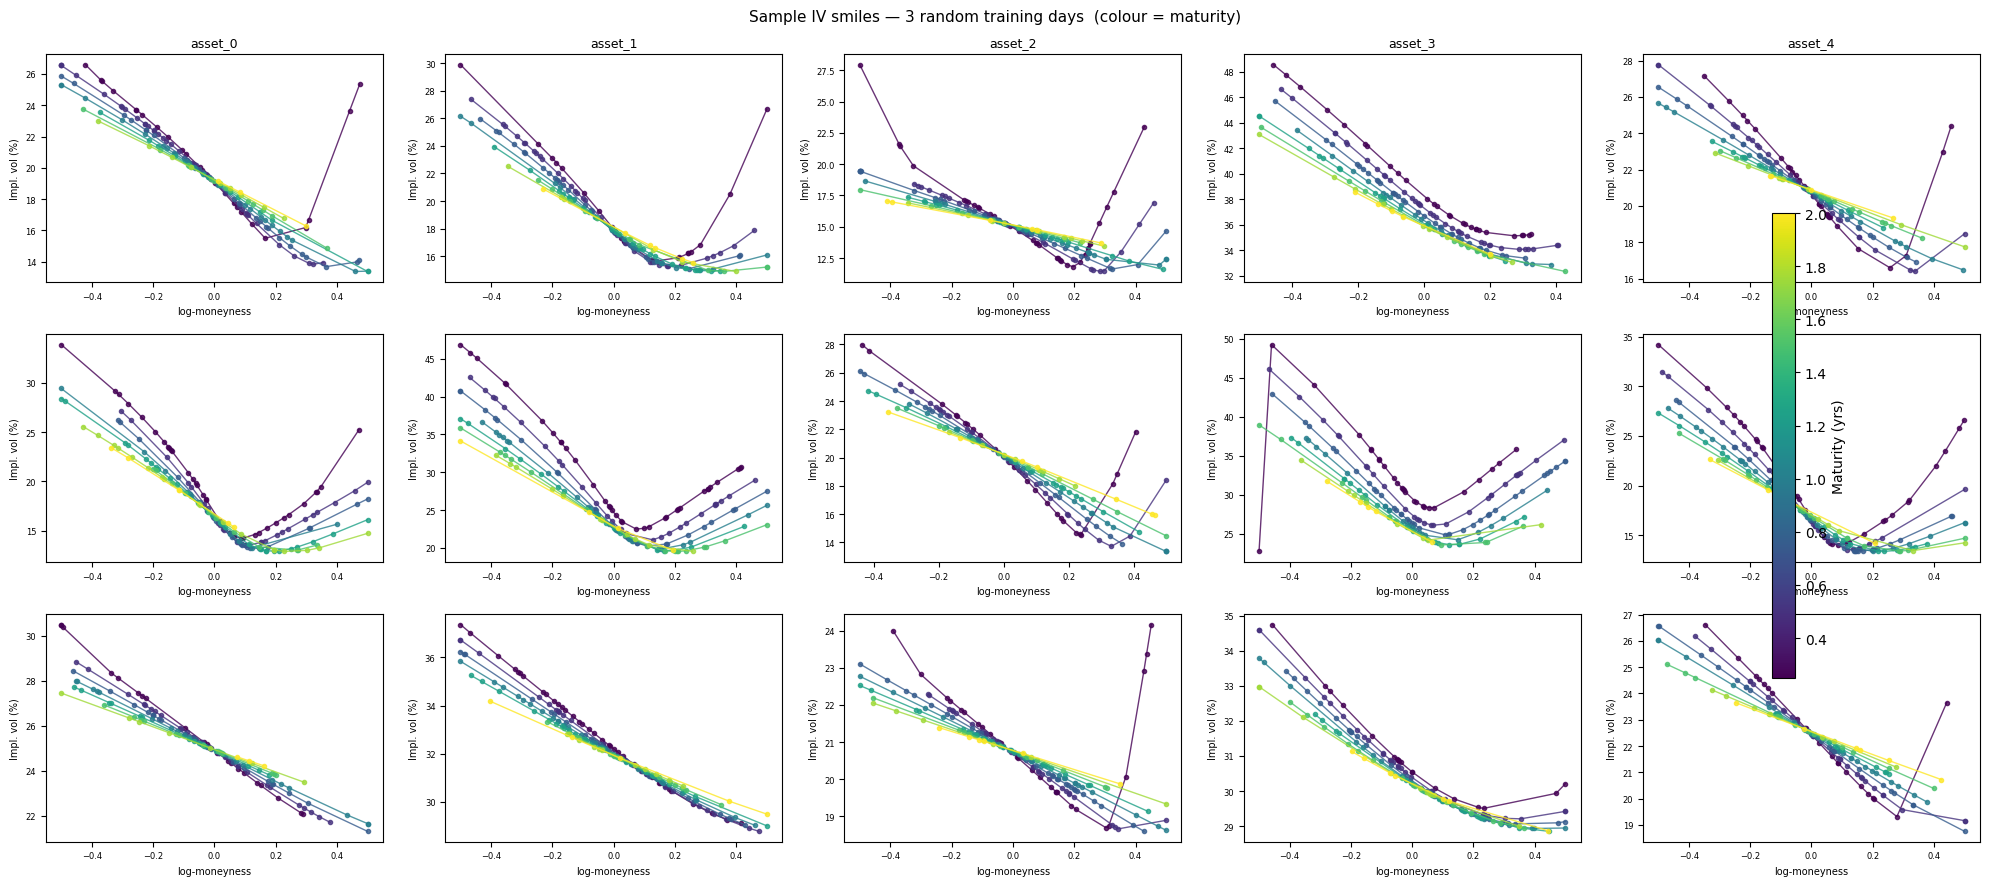

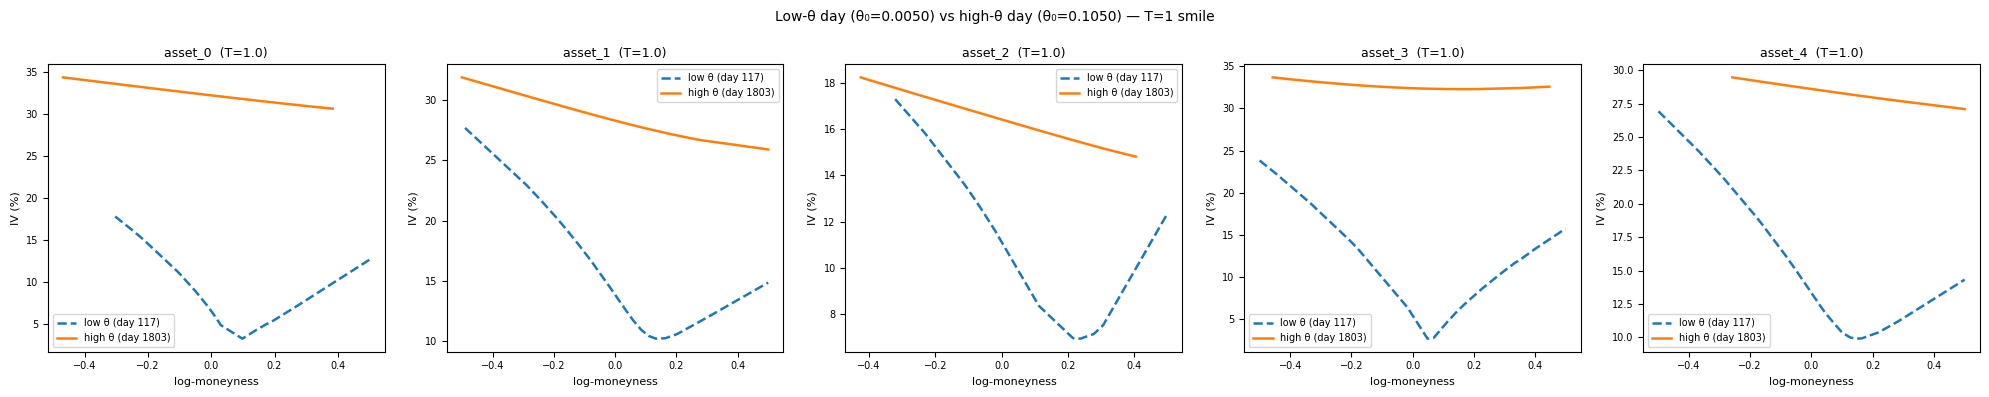

In [67]:
rng_vis  = np.random.default_rng(0)
days_vis = rng_vis.choice(N_DAYS, 3, replace=False)
cmap_vis = plt.cm.viridis
cols     = {T: cmap_vis(i / (N_MAT_BINS - 1)) for i, T in enumerate(MATURITY_BINS)}

fig, axes = plt.subplots(len(days_vis), N_ASSETS,
                          figsize=(4 * N_ASSETS, 3 * len(days_vis)), sharey=False)

for row, d in enumerate(days_vis):
    for col in range(N_ASSETS):
        ax  = axes[row, col]
        for T in MATURITY_BINS:
            mask = (all_aid[d] == col) & (all_T[d] == T)
            if mask.sum() < 2:
                continue
            order = np.argsort(all_lm[d][mask])
            ax.plot(all_lm[d][mask][order], all_iv[d][mask][order] * 100,
                    'o-', ms=3, lw=1, color=cols[T], alpha=0.8)
        if row == 0:
            ax.set_title(f'asset_{col}', fontsize=9)
        if col == 0:
            th_d = theta_path[d]
            kp_d = kappa_path[d]
            ax.set_ylabel(
                f'Day {d}\nθ={[f"{t:.3f}" for t in th_d]}\nκ={[f"{k:.2f}" for k in kp_d]}',
                fontsize=5
            )
        ax.set_xlabel('log-moneyness', fontsize=7)
        ax.set_ylabel('Impl. vol (%)', fontsize=7)
        ax.tick_params(labelsize=6)

sm = plt.cm.ScalarMappable(cmap=cmap_vis, norm=plt.Normalize(MATURITY_BINS[0], MATURITY_BINS[-1]))
fig.colorbar(sm, ax=axes, label='Maturity (yrs)', fraction=0.015)
fig.suptitle('Sample IV smiles — 3 random training days  (colour = maturity)', fontsize=11)
plt.tight_layout()
plt.show()


# Compare high-theta vs low-theta day for asset 0
th0    = theta_path[:, 0]
day_lo = int(np.argmin(th0))
day_hi = int(np.argmax(th0))

fig, axes = plt.subplots(1, N_ASSETS, figsize=(4 * N_ASSETS, 4), sharey=False)
for a in range(N_ASSETS):
    ax = axes[a]
    for d, label, ls in [(day_lo, f'low θ (day {day_lo})', '--'),
                         (day_hi, f'high θ (day {day_hi})', '-')]:
        T_mid = 1.0
        mask = (all_aid[d] == a) & (all_T[d] == T_mid)
        if mask.sum() >= 2:
            order = np.argsort(all_lm[d][mask])
            ax.plot(all_lm[d][mask][order], all_iv[d][mask][order] * 100,
                    ls, lw=1.8, label=label)
    ax.set_title(f'asset_{a}  (T=1.0)', fontsize=9)
    ax.set_xlabel('log-moneyness', fontsize=8)
    ax.set_ylabel('IV (%)', fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

th_lo = theta_path[day_lo, 0]
th_hi = theta_path[day_hi, 0]
fig.suptitle(f'Low-θ day (θ₀={th_lo:.4f}) vs high-θ day (θ₀={th_hi:.4f}) — T=1 smile', fontsize=10)
plt.tight_layout()
plt.show()

## Save Both Output Files

Both files contain: `lm, maturity, asset_id, iv, params, theta_path, kappa_path, xi_path, rho_path, theta_corr, ctx_max`.
The training file also has a `split` field (0=train, 1=val).

In [69]:
import os

# ── Train / val split (chronological) ─────────────────────────────────────────
N_TRAIN = 4500
N_VAL   = N_DAYS - N_TRAIN

split = np.zeros(N_DAYS, dtype=np.int8)
split[N_TRAIN:] = 1   # 0=train, 1=val

print(f'Split: {(split==0).sum()} train days (0-{N_TRAIN-1}) | {(split==1).sum()} val days ({N_TRAIN}-{N_DAYS-1})')
print('(Chronological split preserves OU autocorrelation structure)')
print()

# ── Save training file ────────────────────────────────────────────────────────
out_train = '../Data/heston_multiasset_training.npz'
np.savez_compressed(
    out_train,
    lm         = all_lm,          # (N_DAYS, N_TOTAL)
    maturity   = all_T,           # (N_DAYS, N_TOTAL)
    asset_id   = all_aid,         # (N_DAYS, N_TOTAL)  int8
    iv         = all_iv,          # (N_DAYS, N_TOTAL)
    params     = all_params,      # (N_DAYS, N_ASSETS, 5) = [v0, kappa, theta, xi, rho]
    split      = split,           # (N_DAYS,)
    ctx_max    = np.int32(N_CTX_POOL),
    theta_path = theta_path,      # (N_DAYS, N_ASSETS)
    kappa_path = kappa_path,      # (N_DAYS, N_ASSETS)
    xi_path    = xi_path,         # (N_DAYS, N_ASSETS)
    rho_path   = rho_path,        # (N_DAYS, N_ASSETS)
    theta_corr = THETA_CORR,      # (N_ASSETS, N_ASSETS)
)
size_mb = os.path.getsize(out_train) / 1e6
print(f'Saved training file -> {out_train}  ({size_mb:.1f} MB)')
print(f'  lm/maturity/asset_id/iv : shape {all_lm.shape}')
print(f'  params                  : shape {all_params.shape}  [v0, kappa, theta, xi, rho]')
print(f'  theta/kappa/xi/rho paths: shape {theta_path.shape}')
print(f'  ctx_max                 : {N_CTX_POOL}')
print(f'  split                   : train={int((split==0).sum())}  val={int((split==1).sum())}')
print()

# ── Save OOD test file ────────────────────────────────────────────────────────
out_ood = '../Data/heston_multiasset_ood_test.npz'
np.savez_compressed(
    out_ood,
    lm         = ood_lm,
    maturity   = ood_T,
    asset_id   = ood_aid,
    iv         = ood_iv,
    params     = ood_params,
    ctx_max    = np.int32(N_CTX_POOL),
    theta_path = theta_path_ood,
    kappa_path = kappa_path_ood,
    xi_path    = xi_path_ood,
    rho_path   = rho_path_ood,
    theta_corr = THETA_CORR,
)
size_ood = os.path.getsize(out_ood) / 1e6
print(f'Saved OOD test file  -> {out_ood}  ({size_ood:.1f} MB)')
print(f'  lm/maturity/asset_id/iv : shape {ood_lm.shape}')
print(f'  params                  : shape {ood_params.shape}')
print(f'  SEED_OOD                : {SEED_OOD}  (completely independent from training)')
print()
print('Field descriptions:')
print(f'  lm[:,  :{N_CTX_POOL}] = context pool   (first {N_CTX_POOL} points)')
print(f'  lm[:, {N_CTX_POOL}:]  = target  pool   (last  {N_TGT_POOL} points)')
print()
print('Done.')

Split: 4500 train days (0-4499) | 500 val days (4500-4999)
(Chronological split preserves OU autocorrelation structure)

Saved training file -> ../Data/heston_multiasset_training.npz  (33.1 MB)
  lm/maturity/asset_id/iv : shape (5000, 800)
  params                  : shape (5000, 5, 5)  [v0, kappa, theta, xi, rho]
  theta/kappa/xi/rho paths: shape (5000, 5)
  ctx_max                 : 400
  split                   : train=4500  val=500

Saved OOD test file  -> ../Data/heston_multiasset_ood_test.npz  (1.3 MB)
  lm/maturity/asset_id/iv : shape (200, 800)
  params                  : shape (200, 5, 5)
  SEED_OOD                : 999  (completely independent from training)

Field descriptions:
  lm[:,  :400] = context pool   (first 400 points)
  lm[:, 400:]  = target  pool   (last  400 points)

Done.
